In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def make_pupil_grid(N=256):
    """
    Create a normalized circular pupil grid.

    Coordinates:
        x, y in [-1, 1]
        circular pupil: r <= 1

    Returns:
        X, Y: coordinate grids
        R: radial coordinate
        mask: circular pupil mask
        dx: grid spacing
    """
    x = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, x)
    R = np.sqrt(X**2 + Y**2)
    mask = R <= 1.0
    dx = x[1] - x[0]
    return X, Y, R, mask, dx

In [3]:
def zernike_like_basis(X, Y, mask):
    """
    A small set of low-order Zernike-like modes.

    These are not fully normalized Noll Zernikes.
    For a minimal WFS simulator, this is fine.
    The purpose is to generate and reconstruct typical low-order aberrations.

    Piston is excluded, because Shack-Hartmann WFS cannot measure absolute piston.
    """
    R2 = X**2 + Y**2

    basis = {
        "tip_x": X,
        "tip_y": Y,
        "defocus": 2 * R2 - 1,
        "astig_45": 2 * X * Y,
        "astig_0": X**2 - Y**2,
        "coma_x": (3 * R2 - 2) * X,
        "coma_y": (3 * R2 - 2) * Y,
        "spherical": 6 * R2**2 - 6 * R2 + 1,
    }

    for name in basis:
        basis[name] = np.where(mask, basis[name], np.nan)

    return basis

In [4]:
def numerical_gradient(W, dx):
    """
    Compute numerical gradient of wavefront W.

    np.gradient returns:
        dW/daxis0, dW/daxis1
    Since axis0 is y and axis1 is x:
        dW_dy, dW_dx = np.gradient(...)
    """
    W0 = np.nan_to_num(W, nan=0.0)
    dW_dy, dW_dx = np.gradient(W0, dx, dx)
    return dW_dx, dW_dy

In [5]:
def measure_shack_hartmann_slopes(
    W,
    mask,
    X,
    Y,
    n_lenslets=12,
    min_fill=0.5,
    noise_std=0.0,
    seed=1,
):
    """
    Minimal geometric Shack-Hartmann measurement.

    Each valid lenslet/sub-aperture measures mean local wavefront slope:

        s_x = <dW/dx>
        s_y = <dW/dy>

    Parameters:
        W:
            wavefront map
        mask:
            circular pupil mask
        X, Y:
            coordinate grids
        n_lenslets:
            number of lenslets across the full pupil diameter
        min_fill:
            minimum fraction of a sub-aperture that must lie inside the pupil
        noise_std:
            Gaussian noise added to slope measurements

    Returns:
        centers:
            array of sub-aperture center positions, shape (M, 2)
        slopes:
            array of measured slopes, shape (M, 2)
    """
    dx = X[0, 1] - X[0, 0]
    dWdx, dWdy = numerical_gradient(W, dx)

    edges = np.linspace(-1, 1, n_lenslets + 1)

    centers = []
    slopes = []

    for ix in range(n_lenslets):
        for iy in range(n_lenslets):
            cell = (
                (X >= edges[ix])
                & (X < edges[ix + 1])
                & (Y >= edges[iy])
                & (Y < edges[iy + 1])
            )

            valid = cell & mask
            fill_fraction = valid.sum() / max(cell.sum(), 1)

            if fill_fraction >= min_fill:
                sx = np.mean(dWdx[valid])
                sy = np.mean(dWdy[valid])

                cx = 0.5 * (edges[ix] + edges[ix + 1])
                cy = 0.5 * (edges[iy] + edges[iy + 1])

                centers.append([cx, cy])
                slopes.append([sx, sy])

    centers = np.array(centers)
    slopes = np.array(slopes)

    if noise_std > 0:
        rng = np.random.default_rng(seed)
        slopes += rng.normal(scale=noise_std, size=slopes.shape)

    return centers, slopes

In [6]:
def build_response_matrix(basis, mask, X, Y, n_lenslets=12):
    """
    Build the Shack-Hartmann response matrix.

    The wavefront is written as:

        W(x, y) = sum_j a_j Z_j(x, y)

    The measured slope vector is:

        s = A a + n

    where:
        s = measured SH-WFS slope vector
        A = response matrix
        a = modal coefficients
        n = noise

    Each column of A is the slope signal produced by one basis mode.
    """
    names = list(basis.keys())
    response_columns = []

    reference_centers = None

    for name in names:
        centers, slopes = measure_shack_hartmann_slopes(
            basis[name],
            mask,
            X,
            Y,
            n_lenslets=n_lenslets,
            noise_std=0.0,
        )

        if reference_centers is None:
            reference_centers = centers

        response_columns.append(slopes.reshape(-1))

    A = np.column_stack(response_columns)

    return A, names, reference_centers

In [7]:
def reconstruct_wavefront_from_slopes(slopes, A, basis, names):
    """
    Reconstruct wavefront from SH-WFS slopes using least squares.

    We solve:

        A a = s

    with:

        a_hat = argmin ||A a - s||^2

    The reconstructed wavefront is then:

        W_rec = sum_j a_hat_j Z_j
    """
    s = slopes.reshape(-1)

    coeff_est, residuals, rank, sing_vals = np.linalg.lstsq(
        A,
        s,
        rcond=1e-4,
    )

    W_rec = np.zeros_like(next(iter(basis.values())))

    for coeff, name in zip(coeff_est, names):
        W_rec += coeff * np.nan_to_num(basis[name], nan=0.0)

    pupil_region = np.isfinite(next(iter(basis.values())))
    W_rec = np.where(pupil_region, W_rec, np.nan)

    return coeff_est, W_rec, rank, sing_vals

In [8]:
def plot_results(W_true, W_rec, residual, centers, slopes):
    """
    Plot true wavefront, measured slopes, reconstructed wavefront, and residual.
    """
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    im0 = axes[0].imshow(
        W_true,
        extent=[-1, 1, -1, 1],
        origin="lower",
    )
    axes[0].set_title("True wavefront")
    axes[0].set_xlabel("pupil x")
    axes[0].set_ylabel("pupil y")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    axes[1].quiver(
        centers[:, 0],
        centers[:, 1],
        slopes[:, 0],
        slopes[:, 1],
    )
    axes[1].set_title("Measured local slopes")
    axes[1].set_aspect("equal")
    axes[1].set_xlim(-1, 1)
    axes[1].set_ylim(-1, 1)
    axes[1].set_xlabel("pupil x")
    axes[1].set_ylabel("pupil y")

    im2 = axes[2].imshow(
        W_rec,
        extent=[-1, 1, -1, 1],
        origin="lower",
    )
    axes[2].set_title("Reconstructed wavefront")
    axes[2].set_xlabel("pupil x")
    axes[2].set_ylabel("pupil y")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    im3 = axes[3].imshow(
        residual,
        extent=[-1, 1, -1, 1],
        origin="lower",
    )
    axes[3].set_title("Residual")
    axes[3].set_xlabel("pupil x")
    axes[3].set_ylabel("pupil y")
    plt.colorbar(im3, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

Estimated coefficients
----------------------
tip_x     : true =  0.0500, estimated =  0.0497
tip_y     : true = -0.0300, estimated = -0.0293
defocus   : true =  0.2500, estimated =  0.2494
astig_45  : true = -0.1200, estimated = -0.1202
astig_0   : true =  0.0800, estimated =  0.0806
coma_x    : true =  0.1000, estimated =  0.0994
coma_y    : true = -0.0700, estimated = -0.0697
spherical : true =  0.0400, estimated =  0.0400

Response matrix rank: 8
RMS residual: 6.3180e-04


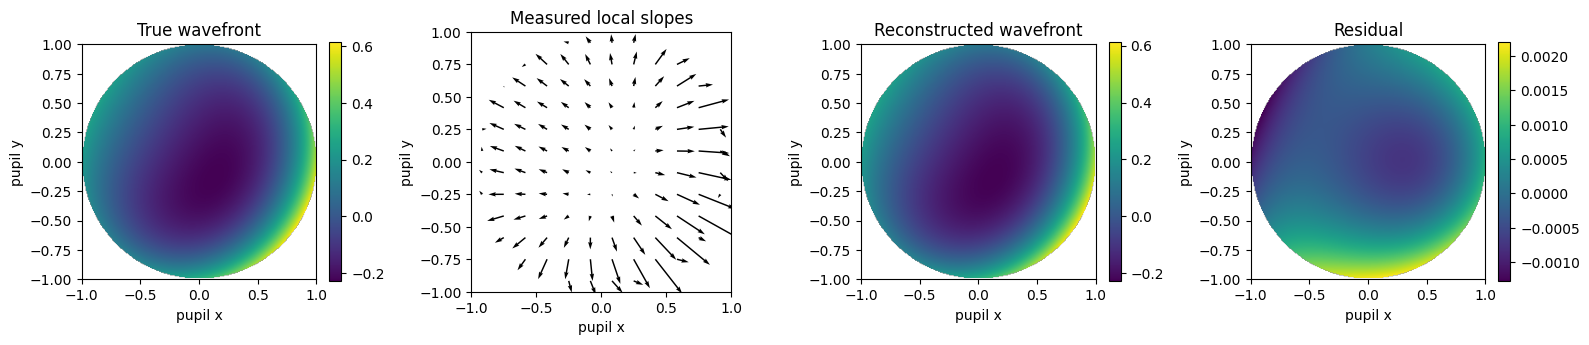

In [10]:
def main():
    # -------------------------
    # 1. Simulation parameters
    # -------------------------
    N = 256
    n_lenslets = 12
    noise_std = 0.01

    # -------------------------
    # 2. Create pupil and modes
    # -------------------------
    X, Y, R, mask, dx = make_pupil_grid(N)
    basis = zernike_like_basis(X, Y, mask)

    # -------------------------
    # 3. Create synthetic true wavefront
    # -------------------------
    # These coefficients are arbitrary units.
    # You can think of them as amplitudes of low-order aberrations.
    true_coeffs = {
        "tip_x": 0.05,
        "tip_y": -0.03,
        "defocus": 0.25,
        "astig_45": -0.12,
        "astig_0": 0.08,
        "coma_x": 0.10,
        "coma_y": -0.07,
        "spherical": 0.04,
    }

    W_true = np.zeros_like(X)

    for name, coeff in true_coeffs.items():
        W_true += coeff * np.nan_to_num(basis[name], nan=0.0)

    W_true = np.where(mask, W_true, np.nan)

    # -------------------------
    # 4. Shack-Hartmann measurement
    # -------------------------
    centers, slopes = measure_shack_hartmann_slopes(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        noise_std=noise_std,
    )

    # -------------------------
    # 5. Build response matrix
    # -------------------------
    A, names, _ = build_response_matrix(
        basis,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
    )

    # -------------------------
    # 6. Reconstruct wavefront
    # -------------------------
    coeff_est, W_rec, rank, sing_vals = reconstruct_wavefront_from_slopes(
        slopes,
        A,
        basis,
        names,
    )

    # Remove piston-like mean offset from residual.
    # SH-WFS cannot measure absolute piston.
    residual = W_true - W_rec
    residual = np.where(mask, residual - np.nanmean(residual), np.nan)

    # -------------------------
    # 7. Print diagnostics
    # -------------------------
    print("Estimated coefficients")
    print("----------------------")

    for name, c_est in zip(names, coeff_est):
        c_true = true_coeffs[name]
        print(f"{name:10s}: true = {c_true: .4f}, estimated = {c_est: .4f}")

    print()
    print(f"Response matrix rank: {rank}")
    print(f"RMS residual: {np.nanstd(residual):.4e}")

    # -------------------------
    # 8. Plot
    # -------------------------
    plot_results(W_true, W_rec, residual, centers, slopes)


if __name__ == "__main__":
    main()